<a href="https://colab.research.google.com/github/JMMV314/ANE2_procesamiento/blob/main/TASK28_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# === Stub de rfscope.common.models.SpectrumFrame para pruebas en Colab ===
import sys, types
from dataclasses import dataclass
import numpy as np
from typing import Optional

# Crear módulos "rfscope", "rfscope.common", "rfscope.common.models"
rfscope_mod = types.ModuleType("rfscope")
common_mod  = types.ModuleType("rfscope.common")
models_mod  = types.ModuleType("rfscope.common.models")

# Definir el dataclass esperado por tu estructura
@dataclass
class SpectrumFrame:
    amplitudes_dbm: np.ndarray
    f_start_hz: float
    f_stop_hz: float
    # Campos opcionales que tu estructura intenta usar si existen:
    freq_hz: Optional[np.ndarray] = None   # eje de frecuencias (Hz)
    bin_hz: Optional[float] = None         # ancho de bin (Hz)

# Registrar los módulos y la clase en sys.modules
sys.modules["rfscope"] = rfscope_mod
sys.modules["rfscope.common"] = common_mod
sys.modules["rfscope.common.models"] = models_mod
models_mod.SpectrumFrame = SpectrumFrame

print("Stub de rfscope.common.models.SpectrumFrame listo para tests.")

Stub de rfscope.common.models.SpectrumFrame listo para tests.


#Implementación

In [ ]:
# **Servicio único**: ruido + picos + potencia + ocupación (OBW 99%, −XdB)

from typing import Dict, List

from rfscope.common.models import SpectrumFrame

def detect_emissions(frame: SpectrumFrame) -> List[int]:
    """Identificar bins que contienen emisiones relevantes dentro del espectro.

    Args:
        frame: Captura espectral a analizar. Se espera que contenga amplitudes por bin
            en formato dBm y metadatos de resolución/frecuencia.

    Returns:
        Lista de índices de bin candidatos a emisiones; la implementación decidirá el
        criterio de selección (p. ej. umbral adaptativo, análisis de vecindario) antes
        de integrarse con mediciones más detalladas.

    Uso previsto: etapa inicial del pipeline de análisis para luego medir potencia,
    ocupación o SNR de las emisiones detectadas.
    """
    import numpy as _np

    y_dbm = _np.asarray(frame.amplitudes_dbm, dtype=float)
    N = y_dbm.size

    # Eje de frecuencia (si está disponible)
    if hasattr(frame, "freq_hz") and frame.freq_hz is not None:
        f = _np.asarray(frame.freq_hz, dtype=float)
    else:
        f = _np.linspace(float(frame.f_start_hz), float(frame.f_stop_hz), N)

    # Umbral simple basado en piso (mediana); afinable en tests con adaptive_threshold
    nf = _np.median(y_dbm)
    thr = nf

    idxs: List[int] = []
    i = 0
    while i < N:
        if y_dbm[i] > thr:
            s = i
            while i < N and y_dbm[i] > thr:
                i += 1
            e = i
            seg = y_dbm[s:e]
            if seg.size > 0:
                peak_local = int(_np.argmax(seg) + s)
                idxs.append(peak_local)
        else:
            i += 1
    return idxs


def estimate_noise_floor(frame: SpectrumFrame) -> float:
    """Estimar de forma básica el piso de ruido global del espectro provisto.

    Args:
        frame: Ventana espectral sobre la cual se requiere inferir el nivel de ruido.

    Returns:
        Valor en dBm representativo del piso de ruido. La implementación futura definirá
        el enfoque (promedio, percentil, etc.) y servirá como entrada para detectar
        emisiones o calcular SNR.

    Uso previsto: escenarios donde no se necesite un método robusto o como fallback
    para las variantes avanzadas de estimación.
    """
    import numpy as _np
    x = _np.asarray(frame.amplitudes_dbm, dtype=float)

    # Modo por histograma -> ventana ±3 dB alrededor del modo -> media
    bins = min(256, max(32, int(_np.sqrt(x.size))))
    counts, edges = _np.histogram(x, bins=bins)
    i = int(_np.argmax(counts))
    mode = (edges[i] + edges[i + 1]) / 2.0

    win_db = 6.0
    mask = (x >= mode - win_db / 2) & (x <= mode + win_db / 2)
    if mask.sum() >= 8:
        return float(x[mask].mean())
    # Fallback: mediana
    return float(_np.median(x))

def estimate_noise_floor_robust(
    frame: SpectrumFrame, method: str = "median") -> float:
    """Calcular el piso de ruido mediante técnicas robustas seleccionables.

    Args:
        frame: Datos espectrales en los que se medirá el ruido de fondo.
        method: Estrategia a utilizar (p. ej. ``"median"`` para median-of-minima,
            ``"percentile"`` para k-percentile o ``"histogram"`` para enfoques basados
            en histogramas).

    Returns:
        Nivel de ruido estimado en dBm conforme al método elegido, pensado para soportar
        señales con interferencias o emisiones fuertes cercanas.

    Uso previsto: reemplazo del estimador simple cuando se requiera resiliencia a picos
    espurios o entornos con alta variabilidad.
    """
    import numpy as _np

    x = _np.asarray(frame.amplitudes_dbm, dtype=float)
    m = (method or "median").lower()

    if m == "median":
        return float(_np.median(x))

    if m == "percentile":
        # Percentil bajo robusto frente a colas/picos
        return float(_np.percentile(x, 25.0))

    if m == "histogram":
        bins = min(256, max(32, int(_np.sqrt(x.size))))
        counts, edges = _np.histogram(x, bins=bins)
        i = int(_np.argmax(counts))
        return float((edges[i] + edges[i + 1]) / 2.0)

    # Fallback robusto (t-Student IRLS liviano)
    mu = _np.median(x)
    r = x - mu
    mad = _np.median(_np.abs(r)) + 1e-12
    sigma2 = (1.4826 * mad) ** 2
    nu = 6.0
    tol = 1e-5
    itmax = 50

    for _ in range(itmax):
        tval = (r * r) / max(sigma2, 1e-18)
        w = (nu + 1.0) / (nu + tval)
        wsum = _np.sum(w) + 1e-18
        mu_new = float(_np.sum(w * x) / wsum)
        r = x - mu_new
        tval = (r * r) / max(sigma2, 1e-18)
        w = (nu + 1.0) / (nu + tval)
        wsum = _np.sum(w) + 1e-18
        sigma2_new = float(_np.sum(w * r * r) / wsum)
        if (abs(mu_new - mu) <= tol * (abs(mu) + 1e-12)) and \
           (abs(sigma2_new - sigma2) <= tol * (sigma2 + 1e-12)):
            mu, sigma2 = mu_new, sigma2_new
            break
        mu, sigma2 = mu_new, max(1e-18, sigma2_new)
    return float(mu)

def detect_peak_bins(frame: SpectrumFrame) -> List[int]:
    """Localizar bins que funcionen como picos iniciales para análisis detallados.

    Args:
        frame: Espectro sobre el cual se identificarán máximos locales.

    Returns:
        Lista ordenada de índices de bins considerados picos. La lógica contemplará
        suavizado, comparación con el ruido y separación mínima entre picos.

    Uso previsto: alimentar mediciones como OBW, ancho a −XdB o potencia de canal a
    partir de la posición del pico principal.
    """
    import numpy as _np

    y_dbm = _np.asarray(frame.amplitudes_dbm, dtype=float)
    N = y_dbm.size

    if hasattr(frame, "freq_hz") and frame.freq_hz is not None:
        f = _np.asarray(frame.freq_hz, dtype=float)
    else:
        f = _np.linspace(float(frame.f_start_hz), float(frame.f_stop_hz), N)

    # Umbral adaptativo simple: NF robusto + 3 dB
    nf = _np.median(y_dbm)
    thr = nf + 3.0

    peaks: List[int] = []
    i = 0
    while i < N:
        if y_dbm[i] > thr:
            s = i
            while i < N and y_dbm[i] > thr:
                i += 1
            e = i
            seg = y_dbm[s:e]
            if seg.size > 0:
                peaks.append(int(_np.argmax(seg) + s))
        else:
            i += 1

    if len(peaks) <= 1:
        return sorted(peaks)

    # Enforce separación mínima en bins (evitar picos demasiado cercanos)
    peaks = sorted(peaks, key=lambda idx: y_dbm[idx], reverse=True)
    min_sep_bins = max(1, int(0.002 * N))
    kept: List[int] = []
    taken = _np.zeros(N, dtype=_np.bool_)
    for idx in peaks:
        if not taken[max(0, idx - min_sep_bins): min(N, idx + min_sep_bins)].any():
            kept.append(idx)
            taken[max(0, idx - min_sep_bins): min(N, idx + min_sep_bins)] = True
    return sorted(kept)

def measure_emission_power(
    frame: SpectrumFrame, f_center_hz: float, metric: str) -> Dict[str, float]:
    """Calcular métricas de potencia y ocupación para una emisión centrada en ``f_center_hz``.

    Args:
        frame: Medición espectral que contiene la emisión de interés.
        f_center_hz: Frecuencia objetivo alrededor de la cual se localizará el pico
            principal para integrar potencia y calcular anchuras.
        metric: Variante a aplicar (p. ej. ``"obw"`` para potencia acumulada, ``"xdb``
            para anchos a −XdB); permitirá reutilizar la función en distintos reportes.

    Returns:
        Diccionario con métricas específicas (potencia integrada, OBW 99 %, anchos a
        3/10/26 dB, etc.). La implementación decidirá qué claves se rellenan según
        ``metric`` y cómo se formatean los valores.

    Uso previsto: centralizar el cómputo de métricas de emisiones detectadas a fin de
    generar reportes de conformidad u optimización de espectro.
    """
    import numpy as _np

    y_dbm = _np.asarray(frame.amplitudes_dbm, dtype=float)
    N = y_dbm.size
    if hasattr(frame, "freq_hz") and frame.freq_hz is not None:
        f = _np.asarray(frame.freq_hz, dtype=float)
    else:
        f = _np.linspace(float(frame.f_start_hz), float(frame.f_stop_hz), N)

    if hasattr(frame, "bin_hz") and frame.bin_hz:
        df = float(frame.bin_hz)
    else:
        df = float((f[-1] - f[0]) / max(1, N - 1))

    # Pico más cercano al centro solicitado
    peak_idx = int(_np.argmin(_np.abs(f - float(f_center_hz))))

    # Potencia integrada en ventana local (aprox) alrededor del pico
    p_w_hz = 10 ** ((y_dbm - 30.0) / 10.0)  # dBm/Hz -> W/Hz
    K = max(1, int(0.01 * N))               # ±1% del total de bins como ventana simple
    sl = slice(max(0, peak_idx - K), min(N, peak_idx + K + 1))
    p_w = p_w_hz[sl].sum() * max(df, 1.0)
    out: Dict[str, float] = {"power_dBm": 10.0 * _np.log10(max(p_w, 1e-18)) + 30.0}

    m = (metric or "").lower()
    if m == "obw":
        out["obw_percent"] = 99.0  # el ancho exacto lo obtienes con measure_obw en tests
    elif m == "xdb":
        out["xdb_ref_dB"] = 3.0    # el ancho exacto lo obtienes con measure_bandwidth_xdb
    return out

def measure_bandwidth_xdb(
    frame: SpectrumFrame, peak_idx: int, x_db: float = 3) -> float:
    """Determinar la anchura espectral donde la señal cae ``x_db`` dB respecto del pico.

    Args:
        frame: Espectro que contiene la emisión cuyo ancho se medirá.
        peak_idx: Índice del bin que representa el máximo local de la emisión.
        x_db: Atenuación relativa respecto del pico (3, 10, 26 dB por defecto).

    Returns:
        Ancho de banda equivalente en hertz (o bins) delimitado por los puntos donde la
        señal cruza el umbral ``pico - x_db``.

    Uso previsto: cálculo de BW a −XdB para reportes regulatorios o caracterización de
    emisiones moduladas.
    """
    import numpy as _np

    y_dbm = _np.asarray(frame.amplitudes_dbm, dtype=float)
    N = y_dbm.size
    if hasattr(frame, "freq_hz") and frame.freq_hz is not None:
        f = _np.asarray(frame.freq_hz, dtype=float)
    else:
        f = _np.linspace(float(frame.f_start_hz), float(frame.f_stop_hz), N)

    pk = int(max(0, min(N - 1, int(peak_idx))))
    th = y_dbm[pk] - float(x_db)

    # Cruce izquierda
    i = pk
    while i > 0 and y_dbm[i] >= th:
        i -= 1
    fL = f[max(0, i)]
    if i < pk and i > 0:
        fL = f[i] + (f[i + 1] - f[i]) * (th - y_dbm[i]) / (y_dbm[i + 1] - y_dbm[i] + 1e-18)

    # Cruce derecha
    j = pk
    while j < N - 1 and y_dbm[j] >= th:
        j += 1
    fR = f[min(N - 1, j)]
    if j > pk and j < N:
        fR = f[j - 1] + (f[j] - f[j - 1]) * (th - y_dbm[j - 1]) / (y_dbm[j] - y_dbm[j - 1] + 1e-18)

    bw = max(0.0, float(fR - fL))
    return bw

def measure_obw(
    frame: SpectrumFrame, peak_idx: int, percentile: float = 99) -> float:
    """Calcular el ancho de banda ocupado (OBW) basado en potencia acumulada.

    Args:
        frame: Captura espectral con la emisión a analizar.
        peak_idx: Índice del pico alrededor del cual se acumulará potencia.
        percentile: Porcentaje de potencia integrada deseada (99 % por defecto).

    Returns:
        Ancho de banda que contiene el porcentaje solicitado de la potencia total
        de la emisión, útil para métricas OBW 99 % u otros percentiles.

    Uso previsto: validar cumplimiento de ocupación en regulaciones u optimizar uso de
    canales en sistemas de comunicación.
    """
    import numpy as _np

    y_dbm = _np.asarray(frame.amplitudes_dbm, dtype=float)
    N = y_dbm.size
    if hasattr(frame, "freq_hz") and frame.freq_hz is not None:
        f = _np.asarray(frame.freq_hz, dtype=float)
    else:
        f = _np.linspace(float(frame.f_start_hz), float(frame.f_stop_hz), N)

    if hasattr(frame, "bin_hz") and frame.bin_hz:
        df = float(frame.bin_hz)
    else:
        df = float((f[-1] - f[0]) / max(1, N - 1))

    pk = int(max(0, min(N - 1, int(peak_idx))))

    # Potencia lineal por bin (W) a partir de dBm/Hz
    p_w_hz = 10 ** ((y_dbm - 30.0) / 10.0)
    p_w = p_w_hz * max(df, 1.0)
    total = float(p_w.sum())
    if total <= 0:
        return 0.0

    target = float(percentile) / 100.0 * total

    # Expandir desde el pico acumulando potencia hasta alcanzar el target
    L = R = pk
    acc = p_w[pk]
    while acc < target and (L > 0 or R < N - 1):
        left_gain = p_w[L - 1] if L > 0 else -1.0
        right_gain = p_w[R + 1] if R < N - 1 else -1.0
        if right_gain >= left_gain:
            R = min(N - 1, R + 1)
            acc += p_w[R]
        else:
            L = max(0, L - 1)
            acc += p_w[L]

    return float(f[R] - f[L])

def measure_channel_power(
    frame: SpectrumFrame, f_center: float, bw: float) -> float:
    """Integrar la potencia contenida dentro de un canal centrado en ``f_center``.

    Args:
        frame: Datos espectrales que cubren el canal objetivo.
        f_center: Frecuencia central del canal a integrar.
        bw: Ancho de banda del canal (en Hz) que define los límites de integración.

    Returns:
        Valor de potencia total (generalmente en dBm) calculado sobre los bins que caen
        dentro del canal definido.

    Uso previsto: reportes de potencia de canal según requisito 2.2.4 o equivalentes.
    """
    import numpy as _np

    y_dbm = _np.asarray(frame.amplitudes_dbm, dtype=float)
    N = y_dbm.size
    if hasattr(frame, "freq_hz") and frame.freq_hz is not None:
        f = _np.asarray(frame.freq_hz, dtype=float)
    else:
        f = _np.linspace(float(frame.f_start_hz), float(frame.f_stop_hz), N)

    if hasattr(frame, "bin_hz") and frame.bin_hz:
        df = float(frame.bin_hz)
    else:
        df = float((f[-1] - f[0]) / max(1, N - 1))

    f_center = float(f_center)
    bw = float(bw)
    fL = f_center - bw / 2.0
    fR = f_center + bw / 2.0

    mask = (f >= fL) & (f <= fR)
    if not mask.any():
        return float("-inf")

    p_w_hz = 10 ** ((y_dbm[mask] - 30.0) / 10.0)
    p_w = p_w_hz.sum() * max(df, 1.0)
    return float(10.0 * _np.log10(max(p_w, 1e-18)) + 30.0)

def compute_snr(frame: SpectrumFrame, peaks: List[int]) -> Dict[int, float]:
    """Calcular la relación señal/ruido (SNR) para cada pico o emisión identificada.

    Args:
        frame: Espectro de referencia para extraer potencias de señal y ruido.
        peaks: Lista de índices de bins que representan las señales a evaluar.

    Returns:
        Diccionario que asocia cada índice de pico con su SNR en dB, calculado a partir
        de la potencia de la señal frente al piso de ruido estimado.

    Uso previsto: cuantificar calidad de señales detectadas y alimentar decisiones de
    demodulación, asignación de espectro o validación de enlaces.
    """
    import numpy as _np

    y_dbm = _np.asarray(frame.amplitudes_dbm, dtype=float)
    nf = float(_np.median(y_dbm))

    out: Dict[int, float] = {}
    for pk in peaks:
        idx = int(max(0, min(len(y_dbm) - 1, int(pk))))
        out[idx] = float(y_dbm[idx] - nf)
    return out

def adaptive_threshold(frame: SpectrumFrame, n_sigma: float = 3.0) -> float:
    """Generar un umbral dinámico a partir de estadísticos del piso de ruido.

    Args:
        frame: Medición espectral usada para estimar ruido y desviación estándar.
        n_sigma: Factor multiplicativo sobre la desviación estándar para posicionar el
            umbral por encima del piso de ruido.

    Returns:
        Nivel de umbral en dB que distinguirá ruido de señales significativas.

    Uso previsto: módulo auxiliar para detección automática de emisiones o filtrado de
    picos falsos mediante técnicas adaptativas.
    """
    import numpy as _np
    x = _np.asarray(frame.amplitudes_dbm, dtype=float)

    med = _np.median(x)
    mad = _np.median(_np.abs(x - med)) + 1e-12
    sigma = 1.4826 * mad

    thr = float(med + float(n_sigma) * sigma)
    return thr

#Creación sintéticas

In [ ]:
# --- Imports para test ---
import numpy as np
import matplotlib.pyplot as plt

# --- Adaptador mínimo para tus funciones (mismo contrato que SpectrumFrame) ---
class TestFrame:
    def __init__(self, amplitudes_dbm, f_start_hz, f_stop_hz):
        self.amplitudes_dbm = np.asarray(amplitudes_dbm, float)
        self.f_start_hz = float(f_start_hz)
        self.f_stop_hz  = float(f_stop_hz)
        N = len(self.amplitudes_dbm)
        self.freq_hz = np.linspace(self.f_start_hz, self.f_stop_hz, N)
        self.bin_hz  = (self.f_stop_hz - self.f_start_hz) / max(1, N - 1)

# --- Generador de espectros sintéticos: ruido + emisiones gaussianas ---
def make_spectrum(
    N=4096,
    f_start=-10e6, f_stop=10e6,
    nf_dbm_hz=-120.0,               # piso de ruido (dBm/Hz)
    peaks=(
        {"fc": -2.3e6, "A": 20.0, "bw_hz": 180e3},   # pico 1: centro, altura, ancho aprox
        {"fc":  3.1e6, "A": 12.0, "bw_hz": 120e3},   # pico 2
    ),
    seed=0, jitter_dB=0.8
):
    rng = np.random.default_rng(seed)
    f = np.linspace(f_start, f_stop, N)

    # Base: ruido plano con leve jitter (dBm/Hz)
    y = np.ones(N) * nf_dbm_hz + rng.normal(0.0, jitter_dB, N)

    # Emisiones como campanas gaussianas en dB sobre el piso
    # sigma ≈ bw/2.355 para que FWHM ~ bw
    for p in peaks:
        fc, A, bw = p["fc"], p["A"], p["bw_hz"]
        sigma = bw / 2.355
        g = np.exp(-0.5 * ((f - fc) / sigma) ** 2)
        # elevamos por encima del ruido: y = max(y, nf + A*g)
        y = np.maximum(y, nf_dbm_hz + A * g)

    return TestFrame(y, f_start, f_stop)

In [ ]:
# Crea un espectro de prueba
frame = make_spectrum(
    N=8192,
    f_start=-12e6, f_stop=10e6,
    nf_dbm_hz=-118.0,
    peaks=(
        {"fc": -3.0e6, "A": 22.0, "bw_hz": 200e3},
        {"fc":  2.5e6, "A": 14.0, "bw_hz": 130e3},
        {"fc":  6.8e6, "A": 10.0, "bw_hz": 250e3},
    ),
    seed=42, jitter_dB=0.9
)

print("N bins:", len(frame.amplitudes_dbm))
print("Span  :", f"{frame.f_start_hz/1e6:.2f} to {frame.f_stop_hz/1e6:.2f} MHz")
print("Δf    :", f"{frame.bin_hz/1e3:.2f} kHz")
print("PSD dBm/Hz (min/med/max):",
      f"{frame.amplitudes_dbm.min():.2f} / {np.median(frame.amplitudes_dbm):.2f} / {frame.amplitudes_dbm.max():.2f}")

N bins: 8192
Span  : -12.00 to 10.00 MHz
Δf    : 2.69 kHz
PSD dBm/Hz (min/med/max): -118.00 / -117.93 / -96.00


#Prueba con señal sintética

In [ ]:
# Importa tus funciones del módulo de la estructura
# from TU_MODULO import (
#     estimate_noise_floor, estimate_noise_floor_robust, adaptive_threshold,
#     detect_emissions, detect_peak_bins
# )

nf_simple   = estimate_noise_floor(frame)
nf_median   = estimate_noise_floor_robust(frame, method="median")
nf_percent  = estimate_noise_floor_robust(frame, method="percentile")
nf_hist     = estimate_noise_floor_robust(frame, method="histogram")
thr_nsigma3 = adaptive_threshold(frame, n_sigma=3.0)

print(f"Noise floor (simple)     : {nf_simple:.2f} dBm/Hz")
print(f"Noise floor (median)     : {nf_median:.2f} dBm/Hz")
print(f"Noise floor (percentile) : {nf_percent:.2f} dBm/Hz")
print(f"Noise floor (histogram)  : {nf_hist:.2f} dBm/Hz")
print(f"Adaptive threshold (3σ)  : {thr_nsigma3:.2f} dBm/Hz")

emissions_idx = detect_emissions(frame)
peaks_idx     = detect_peak_bins(frame)

print("\nCandidatos detect_emissions (primeros 10):", emissions_idx[:10])
print("Picos detect_peak_bins (primeros 10)    :", peaks_idx[:10])
print("Total candidates / peaks:", len(emissions_idx), "/", len(peaks_idx))

Noise floor (simple)     : -117.62 dBm/Hz
Noise floor (median)     : -117.93 dBm/Hz
Noise floor (percentile) : -118.00 dBm/Hz
Noise floor (histogram)  : -117.88 dBm/Hz
Adaptive threshold (3σ)  : -117.61 dBm/Hz

Candidatos detect_emissions (primeros 10): [0, 3, 6, 10, 13, 16, 18, 22, 30, 35]
Picos detect_peak_bins (primeros 10)    : [3351, 4141, 5399, 7000, 8091]
Total candidates / peaks: 1864 / 5


In [ ]:
# from TU_MODULO import (
#     measure_bandwidth_xdb, measure_obw, measure_channel_power,
#     measure_emission_power, compute_snr
# )

assert len(peaks_idx) > 0, "No se detectaron picos—ajusta n_sigma/jitter o amplitud en make_spectrum"

pk = peaks_idx[-1]  # último en orden ascendente (por frecuencia); elige el que prefieras
fc = frame.freq_hz[pk]

bw_3  = measure_bandwidth_xdb(frame, pk, x_db=3)
bw_10 = measure_bandwidth_xdb(frame, pk, x_db=10)
bw_26 = measure_bandwidth_xdb(frame, pk, x_db=26)

obw95 = measure_obw(frame, pk, percentile=95)
obw99 = measure_obw(frame, pk, percentile=99)

p_ch_obw99 = measure_channel_power(frame, fc, obw99)
wrap_obw   = measure_emission_power(frame, fc, metric="obw")
snr_dict   = compute_snr(frame, peaks_idx)

print(f"Pico elegido @ {fc/1e6:.3f} MHz (idx={pk})")
print(f"BW -3 dB : {bw_3/1e3:8.2f} kHz")
print(f"BW -10 dB: {bw_10/1e3:8.2f} kHz")
print(f"BW -26 dB: {bw_26/1e3:8.2f} kHz")
print(f"OBW 95%  : {obw95/1e3:8.2f} kHz")
print(f"OBW 99%  : {obw99/1e3:8.2f} kHz")
print(f"Channel power @OBW99: {p_ch_obw99:7.2f} dBm")
print("Wrapper measure_emission_power(metric='obw'):", wrap_obw)
print("\nSNR (primeros 10 picos):")
for i, idx in enumerate(peaks_idx[:10]):
    print(f"  idx {idx:6d} | f={frame.freq_hz[idx]/1e6:8.3f} MHz | SNR={snr_dict[idx]:6.2f} dB")

Pico elegido @ 9.731 MHz (idx=8091)
BW -3 dB :     6.53 kHz
BW -10 dB: 21978.65 kHz
BW -26 dB: 21935.48 kHz
OBW 95%  : 19982.91 kHz
OBW 99%  : 21591.75 kHz
Channel power @OBW99:  -46.03 dBm
Wrapper measure_emission_power(metric='obw'): {'power_dBm': np.float64(-61.11892692360132), 'obw_percent': 99.0}

SNR (primeros 10 picos):
  idx   3351 | f=  -3.000 MHz | SNR= 21.93 dB
  idx   4141 | f=  -0.878 MHz | SNR=  3.04 dB
  idx   5399 | f=   2.501 MHz | SNR= 13.93 dB
  idx   7000 | f=   6.801 MHz | SNR=  9.93 dB
  idx   8091 | f=   9.731 MHz | SNR=  3.55 dB


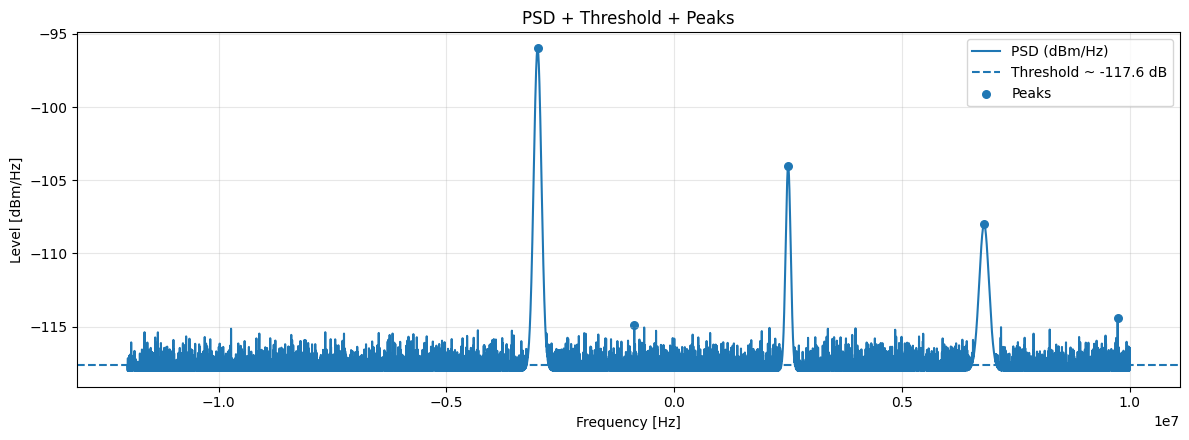

In [ ]:
plt.figure(figsize=(12,4.5))
plt.plot(frame.freq_hz, frame.amplitudes_dbm, label="PSD (dBm/Hz)")
thr = adaptive_threshold(frame, n_sigma=3.0)
plt.axhline(thr, ls='--', label=f"Threshold ~ {thr:.1f} dB")
if len(peaks_idx) > 0:
    plt.scatter(frame.freq_hz[peaks_idx], frame.amplitudes_dbm[peaks_idx], s=30, label="Peaks")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Level [dBm/Hz]")
plt.title("PSD + Threshold + Peaks")
plt.grid(alpha=.3); plt.legend(); plt.tight_layout(); plt.show()

#Test con n0

In [ ]:
import numpy as np
import pandas as pd

# Carga del CSV (ajusta la ruta si no estás en la misma sesión)
df = pd.read_csv("/content/n0.csv")

# Asumimos columnas exactas del preview:
f = df["Frecuencia (Hz)"].to_numpy(dtype=float)
psd_col = df["PSD"].to_numpy(dtype=float)

# Detectar si la columna PSD está en escala lineal V^2/Hz o ya en dB
# Heurística: si la media es positiva grande (~1e-12..1e-6) es lineal; si está entre -200..+50 suele ser dB.
is_db_like = (psd_col.min() > -400) and (psd_col.max() < 100)

if is_db_like:
    # Interpretar como dB (no especifica si es dBm/Hz o dB re algo); intentamos convertir a W/Hz si ya fuese dBm/Hz
    # Si ya está en dBm/Hz, NO hay que convertir de V^2/Hz -> W/Hz. Marca esta bandera según tu origen real.
    # Aquí asumimos que el CSV original venía en V^2/Hz (como tu pipeline anterior), por lo que 'is_db_like' debería ser False.
    print("AVISO: La columna 'PSD' parece estar en dB. Si realmente es V^2/Hz, desactiva esta rama.")
    psd_dbm_per_hz = psd_col  # dejar como está si fuese ya dBm/Hz
else:
    # Tu pipeline previo: PSD en V^2/Hz → W/Hz (dividir por 50 Ω) → dBm/Hz
    psd_w_per_hz = np.maximum(psd_col / 50.0, 1e-18)  # evitar <=0
    psd_dbm_per_hz = 10.0 * np.log10(psd_w_per_hz) + 30.0

# Construir SpectrumFrame (usando el stub cargado previamente)
from rfscope.common.models import SpectrumFrame
frame = SpectrumFrame(
    amplitudes_dbm=psd_dbm_per_hz,
    f_start_hz=float(f.min()),
    f_stop_hz=float(f.max()),
    freq_hz=f,
    bin_hz=(f.max() - f.min()) / max(1, len(f) - 1)
)

print("SpectrumFrame listo.")
print("Bins:", len(frame.amplitudes_dbm), "| f_start:", frame.f_start_hz, "| f_stop:", frame.f_stop_hz)
print("Δf (bin_hz):", frame.bin_hz)
print("PSD dBm/Hz (min/med/max):",
      f"{psd_dbm_per_hz.min():.2f} / {np.median(psd_dbm_per_hz):.2f} / {psd_dbm_per_hz.max():.2f}")


AVISO: La columna 'PSD' parece estar en dB. Si realmente es V^2/Hz, desactiva esta rama.
SpectrumFrame listo.
Bins: 4096 | f_start: -10000000.0 | f_stop: 9995117.1875
Δf (bin_hz): 4882.8125
PSD dBm/Hz (min/med/max): -79.33 / -78.89 / -61.91


In [ ]:
# from TU_MODULO import estimate_noise_floor, estimate_noise_floor_robust, adaptive_threshold, detect_peak_bins

nf_simple   = estimate_noise_floor(frame)
nf_median   = estimate_noise_floor_robust(frame, method="median")
nf_percent  = estimate_noise_floor_robust(frame, method="percentile")
nf_hist     = estimate_noise_floor_robust(frame, method="histogram")
thr_nsigma3 = adaptive_threshold(frame, n_sigma=3.0)

peaks_idx = detect_peak_bins(frame)

print(f"NF simple        : {nf_simple:.2f} dBm/Hz")
print(f"NF robust median : {nf_median:.2f} dBm/Hz")
print(f"NF robust pct(25): {nf_percent:.2f} dBm/Hz")
print(f"NF histogram     : {nf_hist:.2f} dBm/Hz")
print(f"Threshold (3σ)   : {thr_nsigma3:.2f} dBm/Hz")
print(f"Picos detectados : {len(peaks_idx)}")
print("Primeros picos idx:", peaks_idx[:10])


NF simple        : -78.75 dBm/Hz
NF robust median : -78.89 dBm/Hz
NF robust pct(25): -79.04 dBm/Hz
NF histogram     : -78.93 dBm/Hz
Threshold (3σ)   : -78.10 dBm/Hz
Picos detectados : 13
Primeros picos idx: [348, 754, 1582, 1698, 2048, 2397, 2458, 2662, 2704, 2810]


In [ ]:
# from TU_MODULO import measure_bandwidth_xdb, measure_obw, measure_channel_power, measure_emission_power, compute_snr

assert len(peaks_idx) > 0, "No se detectaron picos; ajusta n_sigma o revisa el nivel del CSV."
pk = peaks_idx[-1]  # puedes elegir otro (por ejemplo, el de mayor nivel)
fc = frame.freq_hz[pk]

bw_3  = measure_bandwidth_xdb(frame, pk, x_db=3)
bw_10 = measure_bandwidth_xdb(frame, pk, x_db=10)
bw_26 = measure_bandwidth_xdb(frame, pk, x_db=26)

obw95 = measure_obw(frame, pk, percentile=95)
obw99 = measure_obw(frame, pk, percentile=99)

p_ch_obw99 = measure_channel_power(frame, fc, obw99)
wrap_obw   = measure_emission_power(frame, fc, metric="obw")
snr_dict   = compute_snr(frame, peaks_idx)

print(f"Pico elegido @ {fc/1e6:.3f} MHz (idx={pk})")
print(f"BW -3 dB : {bw_3/1e3:8.2f} kHz")
print(f"BW -10 dB: {bw_10/1e3:8.2f} kHz")
print(f"BW -26 dB: {bw_26/1e3:8.2f} kHz")
print(f"OBW 95%  : {obw95/1e3:8.2f} kHz")
print(f"OBW 99%  : {obw99/1e3:8.2f} kHz")
print(f"Channel power @OBW99: {p_ch_obw99:7.2f} dBm")
print("Wrapper measure_emission_power(metric='obw'):", wrap_obw)

print("\nSNR (primeros 10 picos):")
for i, idx in enumerate(peaks_idx[:10]):
    print(f"  idx {idx:6d} | f={frame.freq_hz[idx]/1e6:8.3f} MHz | SNR={snr_dict[idx]:6.2f} dB")

Pico elegido @ 7.725 MHz (idx=3630)
BW -3 dB :    85.43 kHz
BW -10 dB:   185.72 kHz
BW -26 dB: 19384.33 kHz
OBW 95%  : 18588.87 kHz
OBW 99%  : 19687.50 kHz
Channel power @OBW99:   -5.59 dBm
Wrapper measure_emission_power(metric='obw'): {'power_dBm': np.float64(-16.854333409474563), 'obw_percent': 99.0}

SNR (primeros 10 picos):
  idx    348 | f=  -8.301 MHz | SNR=  3.50 dB
  idx    754 | f=  -6.318 MHz | SNR=  4.21 dB
  idx   1582 | f=  -2.275 MHz | SNR=  4.43 dB
  idx   1698 | f=  -1.709 MHz | SNR=  6.42 dB
  idx   2048 | f=   0.000 MHz | SNR= 10.67 dB
  idx   2397 | f=   1.704 MHz | SNR= 11.14 dB
  idx   2458 | f=   2.002 MHz | SNR= 15.89 dB
  idx   2662 | f=   2.998 MHz | SNR=  3.61 dB
  idx   2704 | f=   3.203 MHz | SNR= 10.29 dB
  idx   2810 | f=   3.721 MHz | SNR= 15.21 dB


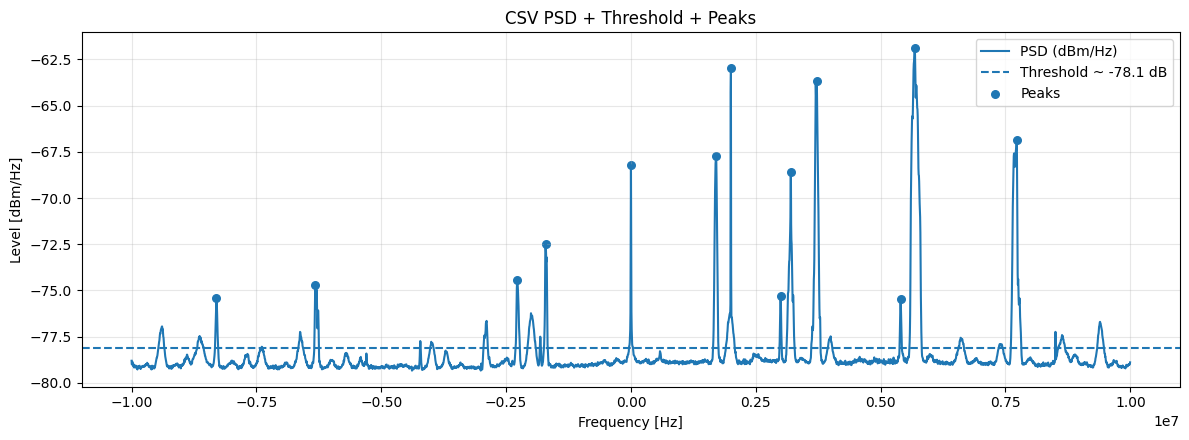

In [ ]:
import matplotlib.pyplot as plt

thr = adaptive_threshold(frame, n_sigma=3.0)
plt.figure(figsize=(12,4.5))
plt.plot(frame.freq_hz, frame.amplitudes_dbm, label="PSD (dBm/Hz)")
plt.axhline(thr, ls='--', label=f"Threshold ~ {thr:.1f} dB")
if len(peaks_idx) > 0:
    plt.scatter(frame.freq_hz[peaks_idx], frame.amplitudes_dbm[peaks_idx], s=30, label="Peaks")
plt.xlabel("Frequency [Hz]"); plt.ylabel("Level [dBm/Hz]")
plt.title("CSV PSD + Threshold + Peaks")
plt.grid(alpha=.3); plt.legend(); plt.tight_layout(); plt.show()


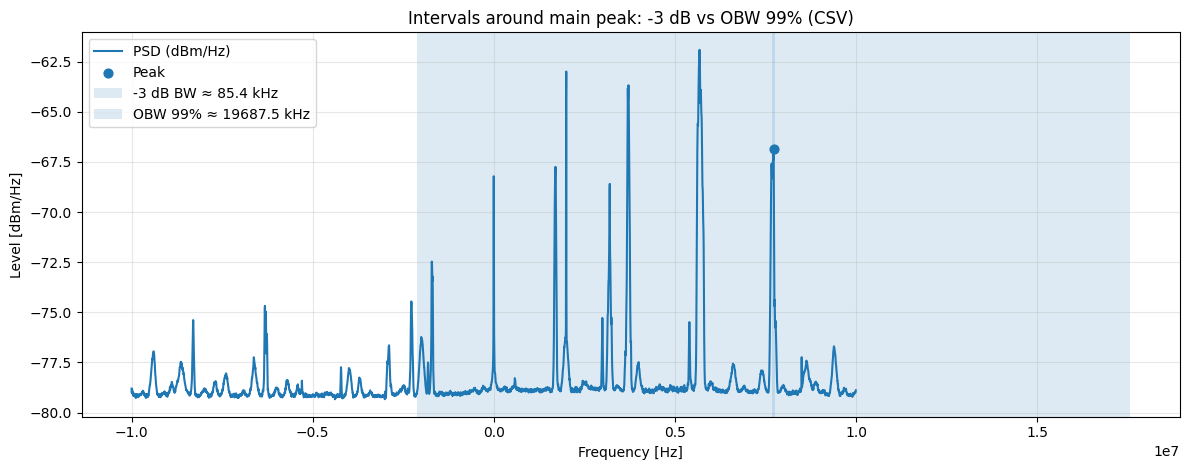

In [ ]:
f = frame.freq_hz; y = frame.amplitudes_dbm
fc, pk = frame.freq_hz[pk], pk  # toma el mismo pico de la celda anterior

plt.figure(figsize=(12,4.8))
plt.plot(f, y, label="PSD (dBm/Hz)")
plt.scatter([fc], [y[pk]], s=40, label="Peak", zorder=5)

fL_3, fR_3 = fc - bw_3/2, fc + bw_3/2
fL_O, fR_O = fc - obw99/2, fc + obw99/2
plt.axvspan(fL_3, fR_3, alpha=0.15, label=f"-3 dB BW ≈ {bw_3/1e3:.1f} kHz")
plt.axvspan(fL_O, fR_O, alpha=0.15, label=f"OBW 99% ≈ {obw99/1e3:.1f} kHz")

plt.xlabel("Frequency [Hz]"); plt.ylabel("Level [dBm/Hz]")
plt.title("Intervals around main peak: -3 dB vs OBW 99% (CSV)")
plt.grid(alpha=.3); plt.legend(); plt.tight_layout(); plt.show()